# Pandas Advance-2 Assignment
### Data Science Masters - PW Skills

## Setup: Base DataFrame

In [1]:
import pandas as pd
import numpy as np

course_name = ['Data Science', 'Machine Learning', 'Big Data', 'Data Engineer']
duration = [2, 3, 6, 4]

df = pd.DataFrame(data={'course_name': course_name, 'duration': duration})
print(df)

        course_name  duration
0      Data Science         2
1  Machine Learning         3
2          Big Data         6
3     Data Engineer         4


## Q1. Print the data present in the second row of the dataframe, df.

In [2]:
# Second row means index 1 (0-based)
print("Second row of the dataframe:")
print(df.iloc[1])

Second row of the dataframe:
course_name    Machine Learning
duration                      3
Name: 1, dtype: object


## Q2. Difference between loc and iloc in pandas DataFrame

In [3]:
"""
loc  → Label-based indexing
      - Uses actual index labels to access rows/columns
      - Syntax: df.loc[row_label, col_label]
      - Both start and end are INCLUSIVE in slicing

iloc → Integer position-based indexing
      - Uses integer positions (0, 1, 2, ...) to access rows/columns
      - Syntax: df.iloc[row_position, col_position]
      - End is EXCLUSIVE in slicing (like regular Python)

Key difference: If index labels are NOT 0,1,2,... then loc and iloc give different results.
"""

# Example to show the difference:
sample = pd.DataFrame({'A': [10, 20, 30]}, index=[5, 10, 15])
print("DataFrame with custom index:")
print(sample)
print("\nsample.loc[10]  → label 10:", sample.loc[10, 'A'])   # row with label 10
print("sample.iloc[1]  → position 1:", sample.iloc[1, 0])    # 2nd row (same row here)

DataFrame with custom index:
     A
5   10
10  20
15  30

sample.loc[10]  → label 10: 20
sample.iloc[1]  → position 1: 20


## Q3. Reindex using [3,0,1,2] and compare loc[2] vs iloc[2]

In [4]:
reindex = [3, 0, 1, 2]
new_df = df.reindex(reindex)

print("new_df after reindexing:")
print(new_df)

print("\nnew_df.loc[2]:")
print(new_df.loc[2])

print("\nnew_df.iloc[2]:")
print(new_df.iloc[2])

print("""
Difference observed:
- new_df.loc[2]  → fetches the row with LABEL 2 → 'Big Data', 6
- new_df.iloc[2] → fetches the row at POSITION 2 (3rd row) → 'Machine Learning', 3
Because after reindexing, the order is [3,0,1,2], so position 2 has label 1 (Machine Learning).
""")

new_df after reindexing:
        course_name  duration
3     Data Engineer         4
0      Data Science         2
1  Machine Learning         3
2          Big Data         6

new_df.loc[2]:
course_name    Big Data
duration              6
Name: 2, dtype: object

new_df.iloc[2]:
course_name    Machine Learning
duration                      3
Name: 1, dtype: object

Difference observed:
- new_df.loc[2]  → fetches the row with LABEL 2 → 'Big Data', 6
- new_df.iloc[2] → fetches the row at POSITION 2 (3rd row) → 'Machine Learning', 3
Because after reindexing, the order is [3,0,1,2], so position 2 has label 1 (Machine Learning).



## Setup: df1 for Q4 and Q5

In [5]:
columns = ['column_1', 'column_2', 'column_3', 'column_4', 'column_5', 'column_6']
indices = [1, 2, 3, 4, 5, 6]

np.random.seed(42)  # for reproducibility
df1 = pd.DataFrame(np.random.rand(6, 6), columns=columns, index=indices)
print(df1)

   column_1  column_2  column_3  column_4  column_5  column_6
1  0.374540  0.950714  0.731994  0.598658  0.156019  0.155995
2  0.058084  0.866176  0.601115  0.708073  0.020584  0.969910
3  0.832443  0.212339  0.181825  0.183405  0.304242  0.524756
4  0.431945  0.291229  0.611853  0.139494  0.292145  0.366362
5  0.456070  0.785176  0.199674  0.514234  0.592415  0.046450
6  0.607545  0.170524  0.065052  0.948886  0.965632  0.808397


## Q4. Statistical measurements for df1

In [6]:
# (i) Mean of each and every column
print("(i) Mean of each column:")
print(df1.mean())

# (ii) Standard deviation of column_2
print("\n(ii) Standard deviation of column_2:")
print(df1['column_2'].std())

(i) Mean of each column:
column_1    0.460104
column_2    0.546026
column_3    0.398585
column_4    0.515458
column_5    0.388506
column_6    0.478645
dtype: float64

(ii) Standard deviation of column_2:
0.3579752740629259


## Q5. Replace 2nd row of column_2 with a string, then find mean

In [7]:
# Convert column to object dtype first to allow string insertion
df1['column_2'] = df1['column_2'].astype(object)
df1.loc[2, 'column_2'] = 'hello'

print("df1['column_2'] after replacement:")
print(df1[['column_2']])
print("\ndtype of column_2:", df1['column_2'].dtype)

# Now try to find the mean
try:
    mean_val = pd.to_numeric(df1['column_2'], errors='coerce').mean()
    print("\nMean of column_2 (ignoring string):", round(mean_val, 4))
except TypeError as e:
    print("\nError:", e)

print("""
Explanation:
When we insert a string into a numeric column, the column dtype changes to 'object'.
Calling .mean() directly on an object column raises a TypeError in newer pandas versions
because arithmetic can't be done on mixed types (floats + string).
We can work around it using pd.to_numeric(..., errors='coerce') which converts
non-numeric values to NaN, then mean() skips NaN automatically.
""")

df1['column_2'] after replacement:
   column_2
1  0.950714
2     hello
3  0.212339
4  0.291229
5  0.785176
6  0.170524

dtype of column_2: object

Mean of column_2 (ignoring string): 0.482

Explanation:
When we insert a string into a numeric column, the column dtype changes to 'object'.
Calling .mean() directly on an object column raises a TypeError in newer pandas versions
because arithmetic can't be done on mixed types (floats + string).
We can work around it using pd.to_numeric(..., errors='coerce') which converts
non-numeric values to NaN, then mean() skips NaN automatically.



## Q6. Window Functions in Pandas

In [ ]:

s = pd.Series([1, 2, 3, 4, 5])

print("Original Series:", s.tolist())
print("Rolling(3) mean:", s.rolling(3).mean().tolist())
print("Expanding mean: ", s.expanding().mean().tolist())
print("EWM mean:       ", s.ewm(span=3).mean().round(3).tolist())

Original Series: [1, 2, 3, 4, 5]
Rolling(3) mean: [nan, nan, 2.0, 3.0, 4.0]
Expanding mean:  [1.0, 1.5, 2.0, 2.5, 3.0]
EWM mean:        [1.0, 1.667, 2.429, 3.267, 4.161]


## Q7. Print current month and year

In [9]:
now = pd.Timestamp.now()
print("Current Month:", now.month_name())
print("Current Year: ", now.year)
print(f"Month & Year: {now.strftime('%B %Y')}")

Current Month: March
Current Year:  2026
Month & Year: March 2026


## Q8. Difference between two dates in days, hours, and minutes

In [ ]:

date1_str = '2024-01-01'  
date2_str = '2024-03-15'

date1 = pd.Timestamp(date1_str)
date2 = pd.Timestamp(date2_str)

delta = date2 - date1

total_seconds = int(delta.total_seconds())
days    = delta.days
hours   = (total_seconds % 86400) // 3600
minutes = (total_seconds % 3600) // 60

print(f"Date 1: {date1_str}")
print(f"Date 2: {date2_str}")
print(f"Difference → {days} days, {hours} hours, {minutes} minutes")

Date 1: 2024-01-01
Date 2: 2024-03-15
Difference → 74 days, 0 hours, 0 minutes


## Q9. Read CSV with categorical data and convert column to categorical type

In [ ]:
import io
csv_data = """Name,Grade,Score
Alice,B,75
Bob,A,92
Charlie,C,60
Diana,A,88
Eve,B,73
Frank,D,50
"""

# Simulate reading from CSV
df_cat = pd.read_csv(io.StringIO(csv_data))

# Simulate user inputs
column_name   = 'Grade'
category_order = ['D', 'C', 'B', 'A']  # low to high

# Convert to categorical with specified order
df_cat[column_name] = pd.Categorical(
    df_cat[column_name],
    categories=category_order,
    ordered=True
)

# Sort by the categorical column
df_sorted = df_cat.sort_values(by=column_name)

print("Sorted Data by Grade (D < C < B < A):")
print(df_sorted)
print("\nColumn dtype:", df_cat[column_name].dtype)

Sorted Data by Grade (D < C < B < A):
      Name Grade  Score
5    Frank     D     50
2  Charlie     C     60
0    Alice     B     75
4      Eve     B     73
1      Bob     A     92
3    Diana     A     88

Column dtype: category


## Q10. Stacked bar chart for sales data by product category over time

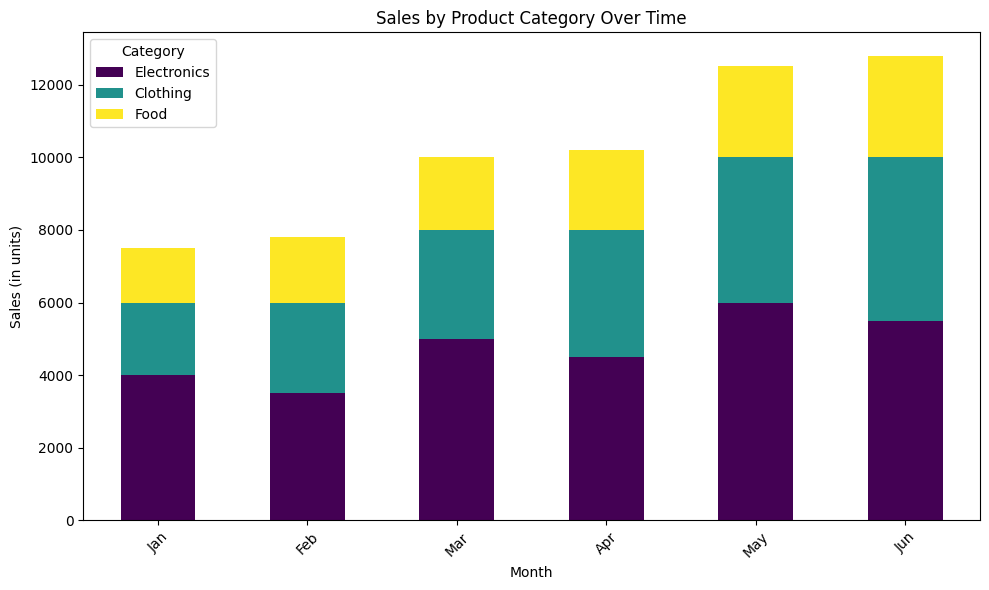

       Electronics  Clothing  Food
Month                             
Jan           4000      2000  1500
Feb           3500      2500  1800
Mar           5000      3000  2000
Apr           4500      3500  2200
May           6000      4000  2500
Jun           5500      4500  2800


In [ ]:
import matplotlib.pyplot as plt
import io


sales_csv = """Month,Electronics,Clothing,Food
Jan,4000,2000,1500
Feb,3500,2500,1800
Mar,5000,3000,2000
Apr,4500,3500,2200
May,6000,4000,2500
Jun,5500,4500,2800
"""

df_sales = pd.read_csv(io.StringIO(sales_csv))
df_sales.set_index('Month', inplace=True)

df_sales.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')

plt.title('Sales by Product Category Over Time')
plt.xlabel('Month')
plt.ylabel('Sales (in units)')
plt.xticks(rotation=45)
plt.legend(title='Category')
plt.tight_layout()
plt.show()

print(df_sales)

## Q11. Read student CSV and calculate Mean, Median, Mode of test scores

In [ ]:
import io

student_csv = """Student ID,Test Score
1,85
2,90
3,80
4,75
5,85
6,82
7,78
8,85
9,90
10,85
"""

df_students = pd.read_csv(io.StringIO(student_csv))

mean_score   = df_students['Test Score'].mean()
median_score = df_students['Test Score'].median()
mode_scores  = df_students['Test Score'].mode().tolist()
mode_str     = ', '.join(map(str, mode_scores))

# Display in table format
print("+-----------+--------+")
print("| Statistic | Value  |")
print("+-----------+--------+")
print(f"| Mean      | {mean_score:<6} |")
print(f"| Median    | {median_score:<6} |")
print(f"| Mode      | {mode_str:<6} |")
print("+-----------+--------+")

+-----------+--------+
| Statistic | Value  |
+-----------+--------+
| Mean      | 83.5   |
| Median    | 85.0   |
| Mode      | 85     |
+-----------+--------+
